# Read data from csv that contains combined defenders statistics and their respective seasonal ratings for past three seasons.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("finalized_players.csv")

In [3]:
print(df.shape)

(3652, 35)


# Now, we want to see if there are any entries of players without seasonal ratings, if so, exclude them from the data.

In [4]:
print(df[df.isnull().any(axis=1)])

                Player Name    Pos           Squad          League   90s  Tkl  \
17         Anel Ahmedhodžić     DF   Sheffield Utd  Premier League  29.4   64   
19          Rayan Aït-Nouri  DF,MF          Wolves  Premier League  25.9   71   
44     Michael Amir Murillo     DF       Marseille         Ligue 1  11.1   23   
50       Miguel Ángel Rubio     DF         Granada         La Liga  17.3   20   
56         Oliver Arblaster     MF   Sheffield Utd  Premier League  10.5   23   
...                     ...    ...             ...             ...   ...  ...   
3579  José Luis García Vayá     MF         Levante         La Liga  22.4   46   
3590         Freddie Veseli     DF     Salernitana         Serie A   6.6    7   
3609     Kyle Walker-Peters     DF     Southampton  Premier League  29.3   57   
3610      Aaron Wan-Bissaka     DF  Manchester Utd  Premier League  19.9   49   
3612      James Ward-Prowse     MF     Southampton  Premier League  35.7   41   

      TklW  Def 3rd  Mid 3r

# We see we have 131 players who do not have ratings, so we are going to exclude them to produce a "cleaned" DataFrame

In [5]:
df_clean = df.dropna()

In [6]:
# Ensure that the number of rows of players with NaN values summed with the rows of the clean df equal the original
# number of rows. Also that our cleaned df contains no NaN values
print(df_clean.shape)
print(df_clean[df_clean.isnull().any(axis=1)])

(3521, 35)
Empty DataFrame
Columns: [Player Name, Pos, Squad, League, 90s, Tkl, TklW, Def 3rd, Mid 3rd, Att 3rd, Chl-Tkl, Att, Tkl%, Chl-Lost, Blocks, Sh, Pass, Int, Tkl+Int, Clr, Err, CrdY, CrdR, 2CrdY, Fls, Off, Crs, PKcon, OG, Recov, Won, Lost, Won%, Season, Rating]
Index: []

[0 rows x 35 columns]


In [7]:
print(df_clean)

            Player Name    Pos          Squad          League   90s  Tkl  \
0            Max Aarons     DF    Bournemouth  Premier League  13.7   29   
1      Yunis Abdelhamid     DF          Reims         Ligue 1  30.9   64   
2     Salis Abdul Samed     MF           Lens         Ligue 1  16.9   21   
3       Laurent Abergel     MF        Lorient         Ligue 1  31.8   85   
4                 Abner     DF          Betis         La Liga  15.6   25   
...                 ...    ...            ...             ...   ...  ...   
3647       Nadir Zortea  DF,MF    Salernitana         Serie A  15.7   21   
3648         Kurt Zouma     DF       West Ham  Premier League  23.1   11   
3649      Igor Zubeldia     DF  Real Sociedad         La Liga  18.3   20   
3650   Martín Zubimendi     MF  Real Sociedad         La Liga  28.8   52   
3651   Szymon Żurkowski     MF         Empoli         Serie A  25.6   58   

      TklW  Def 3rd  Mid 3rd  Att 3rd  ...  Off  Crs  PKcon  OG  Recov  Won  \
0       

In [8]:
print(df_clean.dtypes)

Player Name     object
Pos             object
Squad           object
League          object
90s            float64
Tkl              int64
TklW             int64
Def 3rd          int64
Mid 3rd          int64
Att 3rd          int64
Chl-Tkl          int64
Att              int64
Tkl%           float64
Chl-Lost         int64
Blocks           int64
Sh               int64
Pass             int64
Int              int64
Tkl+Int          int64
Clr              int64
Err              int64
CrdY             int64
CrdR             int64
2CrdY            int64
Fls              int64
Off              int64
Crs              int64
PKcon            int64
OG               int64
Recov            int64
Won              int64
Lost             int64
Won%           float64
Season          object
Rating         float64
dtype: object


# Also, need to drop columns such as Name, Squad, and League.

In [9]:
df_processed = df_clean.drop(columns=["Player Name", "Squad", "League", "Season"])

In [10]:
# Ensure we removed the correct number of columns
print(df_processed.shape)

(3521, 31)


In [11]:
# Now, we want to transform the player's position using One-Hot Encoding, but first we need to keep consistency
# in positions. We need to modify the players who are MF, DF to be DF, MF. This ensure we only have 3 different positions
df_processed['Pos'] = df_processed['Pos'].replace('MF,DF', 'DF,MF')

In [12]:
# Ensure we only have three positions to properly apply ONE-HOT Encoding.
df_processed['Pos'].unique()

array(['DF', 'MF', 'DF,MF'], dtype=object)

In [13]:
df_encoded = pd.get_dummies(df_processed, columns=["Pos"], drop_first=True)
df_encoded = df_encoded.astype({'Pos_DF,MF': 'int', 'Pos_MF': 'int'})


In [14]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['Rating'])
y = df_encoded['Rating']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

first_model = LinearRegression()
first_model.fit(X_train, y_train)

y_pred = first_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Linear Regression MSE: {mse:.5f}, R^2: {r2:.5f}")

Linear Regression MSE: 0.02956, R^2: 0.50440


In [17]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
print(f"Ridge Regression MSE: {mse_ridge:.5f}, R^2: {r2_ridge:.5f}")

Ridge Regression MSE: 0.02956, R^2: 0.50439


In [18]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1.0)

lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
print(f"Lasso Regression MSE: {mse_lasso:.5f}, R^2: {r2_lasso:.5f}")

Lasso Regression MSE: 0.03986, R^2: 0.33168


In [19]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(random_state=42)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)
print(f"Decision Tree Regression MSE: {mse_tree:.5f}, R^2: {r2_tree:.5f}")

Decision Tree Regression MSE: 0.06693, R^2: -0.12227


In [20]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest MSE: {mse_rf:.5f}, R^2: {r2_rf:.5f}")

Random Forest MSE: 0.02965, R^2: 0.50278


In [21]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)
print(f"Gradient Boosting MSE: {mse_gb:.5f}, R^2: {r2_gb:.5f}")

Gradient Boosting MSE: 0.02944, R^2: 0.50637


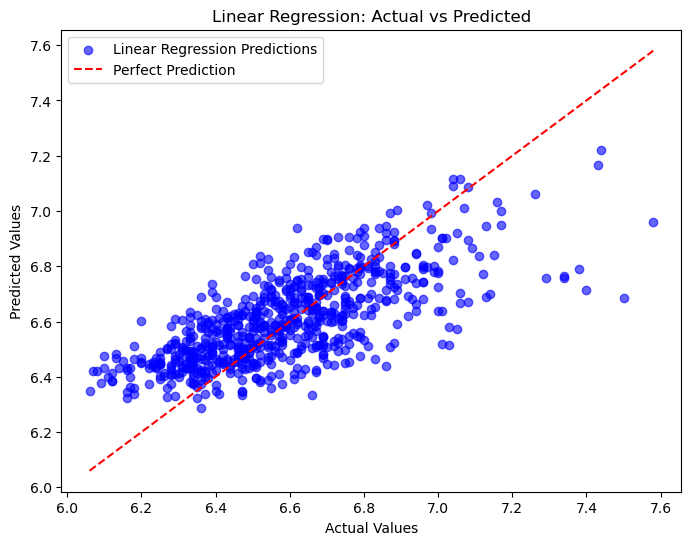

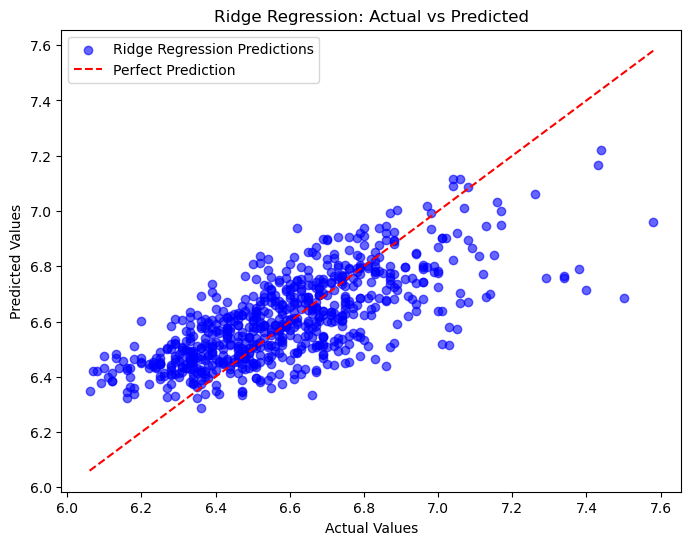

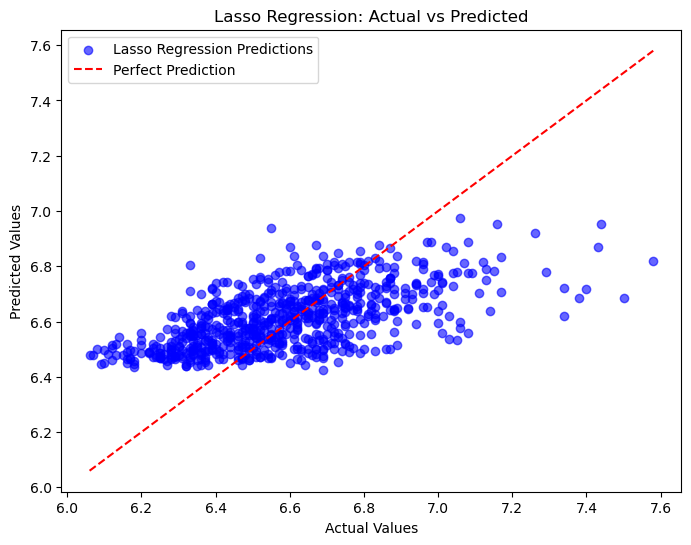

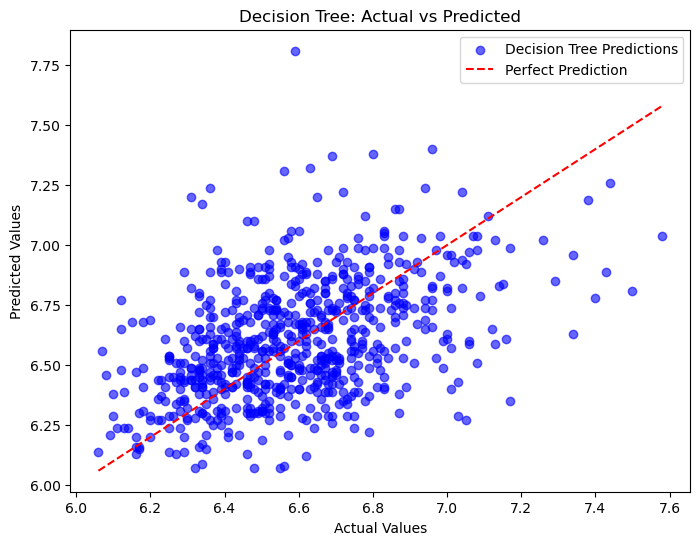

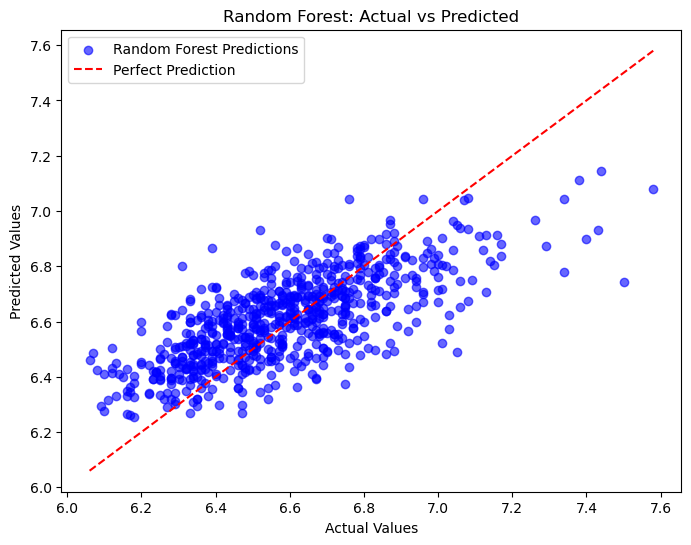

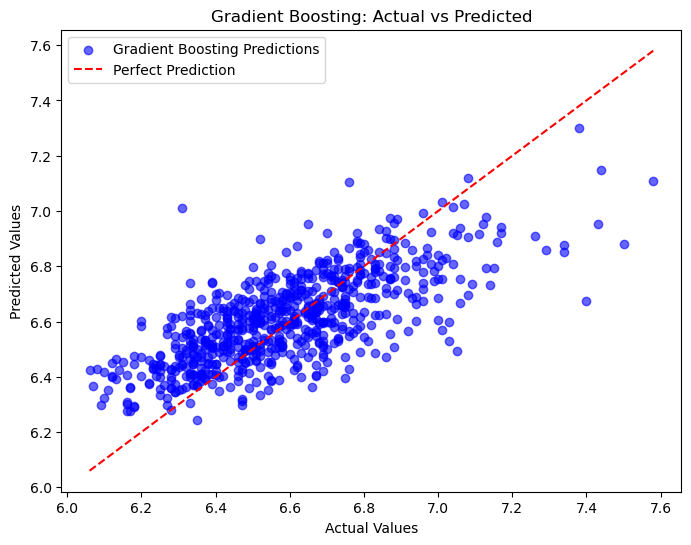

In [22]:
import matplotlib.pyplot as plt

def plot_actual_vs_predicted(y_test, y_pred, model_name):
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, color='blue', alpha=0.6, label=f'{model_name} Predictions')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label="Perfect Prediction")
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'{model_name}: Actual vs Predicted')
    plt.legend()
    plt.show()

plot_actual_vs_predicted(y_test, y_pred, "Linear Regression")
plot_actual_vs_predicted(y_test, y_pred_ridge, "Ridge Regression")
plot_actual_vs_predicted(y_test, y_pred_lasso, "Lasso Regression")
plot_actual_vs_predicted(y_test, y_pred_tree, "Decision Tree")
plot_actual_vs_predicted(y_test, y_pred_rf, "Random Forest")
plot_actual_vs_predicted(y_test, y_pred_gb, "Gradient Boosting")

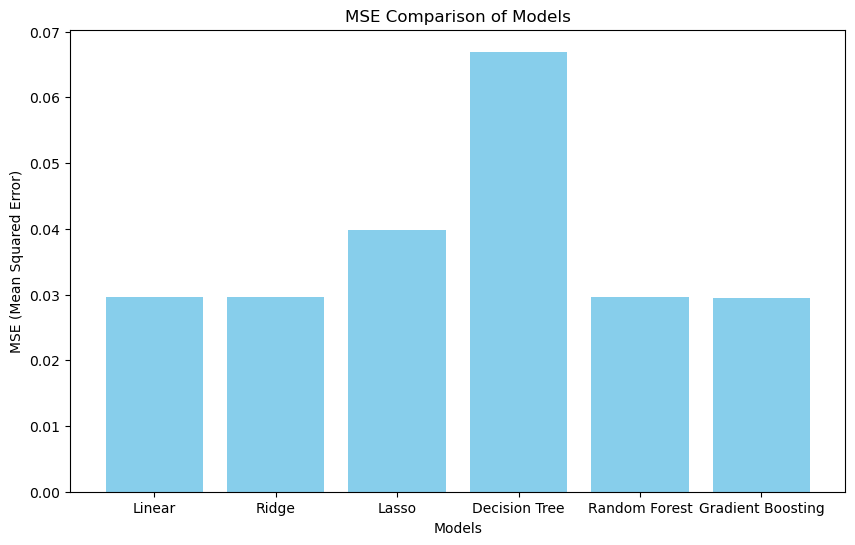

In [23]:
# Create a comparison bar plot for MSE values of each model
models = ['Linear', 'Ridge', 'Lasso', 'Decision Tree', 'Random Forest', 'Gradient Boosting']
mse_values = [mse, mse_ridge, mse_lasso, mse_tree, mse_rf, mse_gb]

plt.figure(figsize=(10, 6))
plt.bar(models, mse_values, color='skyblue')
plt.xlabel('Models')
plt.ylabel('MSE (Mean Squared Error)')
plt.title('MSE Comparison of Models')
plt.show()

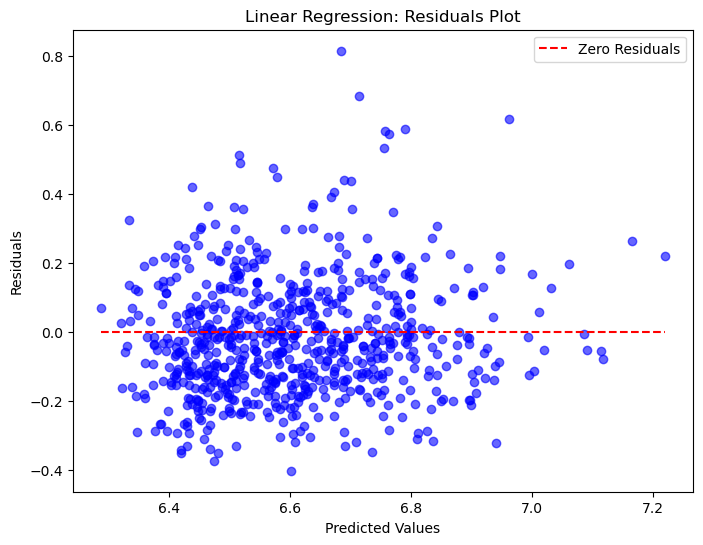

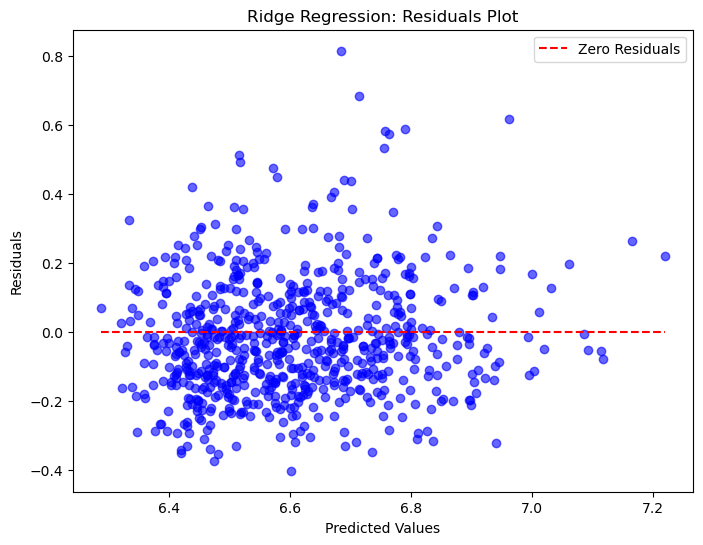

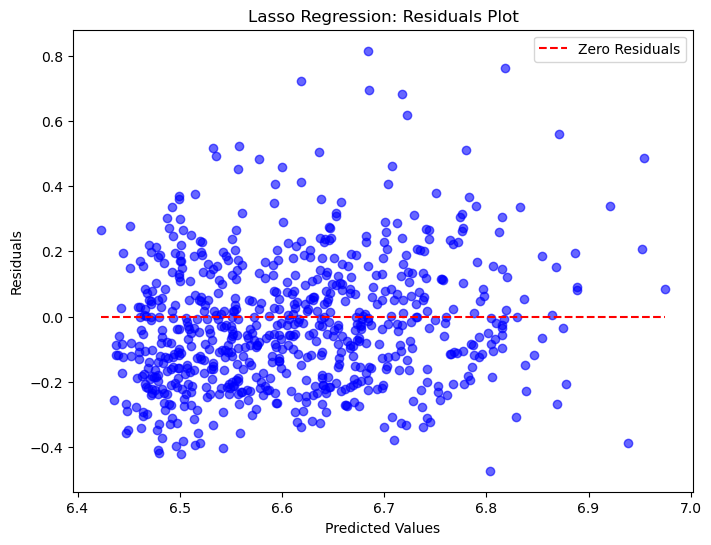

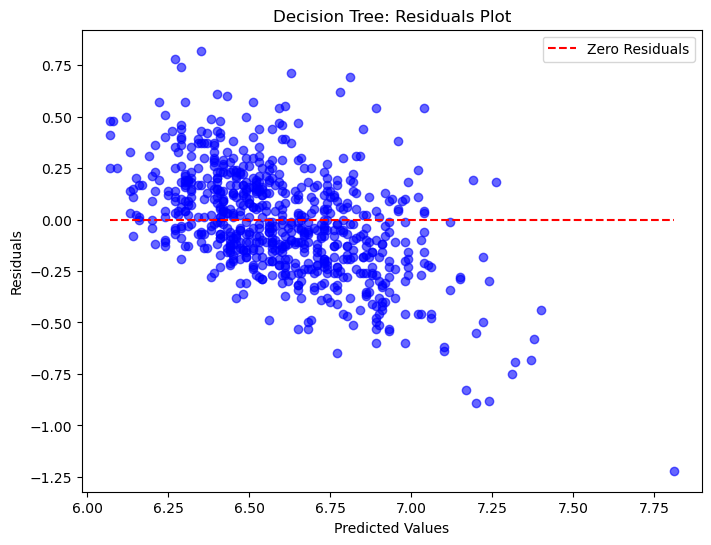

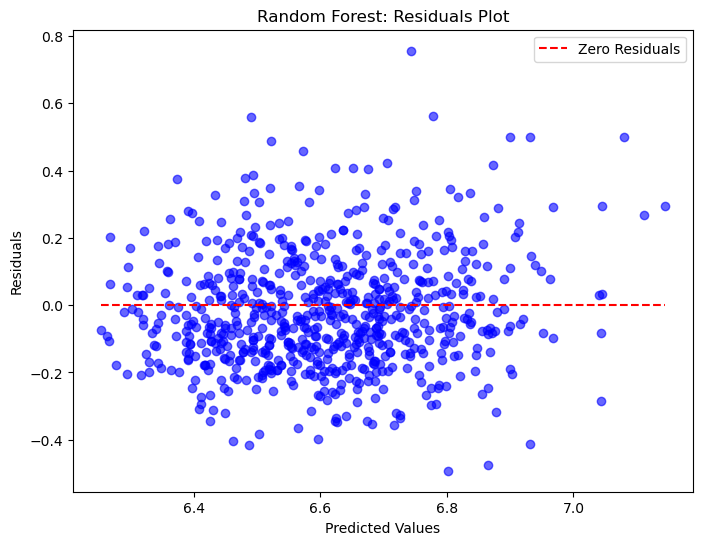

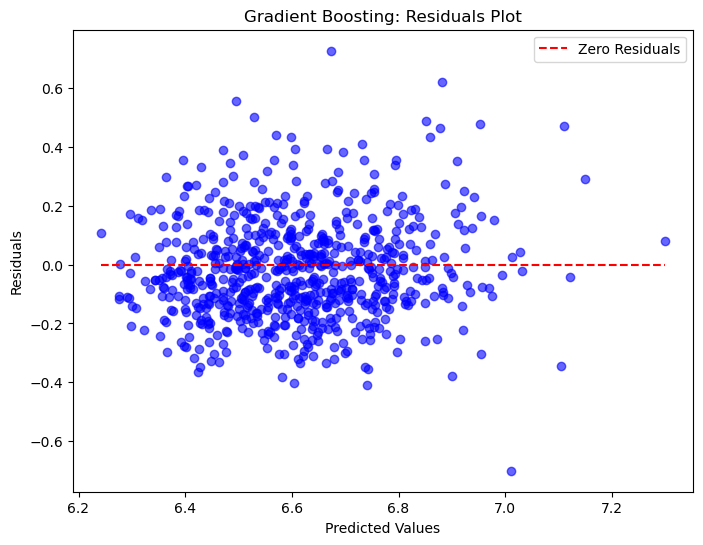

In [25]:
def plot_residuals(y_test, y_pred, model_name):
    residuals = y_test - y_pred
    plt.figure(figsize=(8, 6))
    plt.scatter(y_pred, residuals, color='blue', alpha=0.6)
    plt.hlines(y=0, xmin=y_pred.min(), xmax=y_pred.max(), colors='red', linestyle='--', label="Zero Residuals")
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.title(f'{model_name}: Residuals Plot')
    plt.legend()
    plt.show()

# Residual plot for each model
plot_residuals(y_test, y_pred, "Linear Regression")
plot_residuals(y_test, y_pred_ridge, "Ridge Regression")
plot_residuals(y_test, y_pred_lasso, "Lasso Regression")
plot_residuals(y_test, y_pred_tree, "Decision Tree")
plot_residuals(y_test, y_pred_rf, "Random Forest")
plot_residuals(y_test, y_pred_gb, "Gradient Boosting")